# Анализ пространственно-временной динамики ареала лебедей в Северной Америке
---

**Выполнила проекта: Флоря Виктория**  
**Дата: 25.09.2026**


---

## Тема проекта

**Анализ пространственно-временной динамики ареала лебедей в Северной Америке.**

---

## Цель проекта

Определить, наблюдается ли статистически значимое смещение ареала лебедей в Северной Америке, и выявить, различается ли это смещение в разных географических зонах. Оценить влияние внешних факторов (температура, плотность населения) на пространственное распределение птиц.

---

## Задачи проекта

1. Загрузить и очистить данные о наблюдениях за лебедями.
2. Добавить внешние данные (плотность населения и температура по штатам и провинциям).
3. Провести кластерный анализ для выделения географических зон.
4. Учесть сезонность и другие искажающие факторы.
5. Провести статистический анализ: оценить тренды, сравнить виды и сезоны.
6. Построить визуализации (не менее 4 графиков).
7. Сформулировать выводы.

---

# Описание датасетов

---

## 1. `short.csv` — наблюдения за лебедями

**Источник:** GBIF (Global Biodiversity Information Facility)

**Объём:** ~3.5 млн записей

| Столбец | Тип | Описание |
|---------|-----|----------|
| `gbifID` | int | Уникальный идентификатор наблюдения |
| `basisOfRecord` | str | Тип записи |
| `recordedBy` | str | Наблюдатель |
| `eventDate` | str | Дата наблюдения |
| `year` | int | Год |
| `month` | int | Месяц |
| `day` | int | День |
| `countryCode` | str | Код страны |
| `stateProvince` | str | Штат / провинция |
| `locality` | str | Локация |
| `decimalLatitude` | float | Широта |
| `decimalLongitude` | float | Долгота |
| `coordinateUncertaintyInMeters` | float | — |
| `coordinatePrecision` | float | — |
| `infraspecificEpithet` | float | — |
| `taxonRank` | str | Ранг таксона |
| `datasetKey` | str | Идентификатор источника |
| `elevation` | float | — |
| `elevationAccuracy` | float | — |
| `depth` | float | — |
| `depthAccuracy` | float | — |
| `species` | str | Вид |

**Виды в датасете:**
- `Cygnus olor` — лебедь-шипун
- `Cygnus buccinator` — лебедь-трубач
- `Cygnus columbianus` — американский тундровый лебедь
- `Cygnus atratus` — чёрный лебедь
- `Cygnus cygnus` — лебедь-кликун
- `Cygnus melancoryphus` — черношейный лебедь

---

## 2. `US_CA.csv` — плотность населения

**Объём:** 69 записей

| Столбец | Тип | Описание |
|---------|-----|----------|
| `state_province` | str | Название штата / провинции |
| `land_area` | float | Площадь, км² |
| `density_per` | float | Плотность населения, чел/км² |

---

## 3. `us_state_temperatures.csv` — температуры США

**Объём:** ~26 868 записей

| Столбец | Тип | Описание |
|---------|-----|----------|
| `state` | str | Название штата |
| `year` | int | Год |
| `month` | int | Месяц |
| `avg_temp_f` | float | Температура, °F |
| `avg_temp_c` | float | Температура, °C |

---

## 4. `canada_temperatures.csv` — температуры Канады

**Объём:** 6 864 записи

| Столбец | Тип | Описание |
|---------|-----|----------|
| `state_province` | str | Название провинции |
| `year` | int | Год |
| `month` | int | Месяц |
| `avg_temp_c` | float | Температура, °C |

---

# Задания по предобработке

Выполните следующие шаги в отдельных ячейках ноутбука.

---

### Блок 1. Загрузка и первичный осмотр

1. Загрузите `short.csv`.
2. Выведите `info()`, `shape` и список столбцов.
3. Проверьте количество пропусков по каждому столбцу.

### Блок 2. Очистка структуры данных

4. Удалите столбцы, полностью состоящие из пропусков.
5. Удалите столбец `locality`.
6. Приведите названия столбцов к формату `snake_case` (все буквы строчные, слова разделены `_`).
7. Преобразуйте столбец `event_date` в формат `datetime`.

### Блок 3. Фильтрация данных

8. Оставьте только три вида: `Cygnus olor`, `Cygnus buccinator`, `Cygnus columbianus`.
9. Оставьте только наблюдения из США и Канады (`US`, `CA`).
10. Проверьте и при необходимости ограничьте координаты: широта 25–75°, долгота −170…−35°.
11. Удалите столбцы с единственным уникальным значением.
12. Оставьте только годы **до 2023 включительно**.

### Блок 4. Обогащение данными

13. Загрузите `US_CA.csv`. Проверьте и приведите названия штатов/провинций к единому виду с основным датасетом.
14. Объедините основной датасет с данными о плотности населения.
15. Загрузите оба датасета с температурой.
16. Приведите температуры США и Канады к единому формату (названия столбцов, единицы измерения).
17. Объедините их в один датасет температур.
18. Проверьте уникальность пар `(state_province, year, month)`.

### Блок 5. Сезонная фильтрация

19. Оставьте только месяцы:
    - **Зимовка:** декабрь, январь, февраль
    - **Гнездование:** июнь, июль, август
20. Создайте столбец `period_type`: `1` для зимовки, `2` для гнездования.

### Блок 6. Временная разбивка

21. Разделите данные на 5 временных периодов:
    - `1_1980-1988`
    - `2_1989-1997`
    - `3_1998-2006`
    - `4_2007-2015`
    - `5_2016-2023`
22. Создайте столбец `time_period`.

### Блок 7. Работа с координатами и дубликатами

23. Округлите `decimal_latitude` и `decimal_longitude` до целых чисел.
24. Удалите дубликаты по набору `(year, period_type, decimal_longitude, decimal_latitude, species)`.

### Блок 8. Объединение с температурой

25. Объедините датасет с `temperatures_US_CA` по ключу `(state_province, year, month)`.
26. Проверьте пропуски в температуре. Заполните их средним значением по `(state_province, month)`.

### Блок 9. Сохранение и финальная проверка

27. Сохраните подготовленный датасет в `data_seasonal_enriched.csv`.
28. Выведите:
    - общее количество записей,
    - распределение по периодам,
    - распределение по видам,
    - среднюю температуру по сезонам,
    - среднюю широту по сезонам.

---

# Рекомендуемые статистические методы

Ниже — перечень методов, которые можно применять. Выбирайте в зависимости от вопроса.

---

### 1. Кластерный анализ (обязательно)

**Зачем:** разделить наблюдения на географические зоны.

**Пример:**
```python
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.preprocessing import StandardScaler

coords = df[['decimal_latitude', 'decimal_longitude']].values
coords_scaled = StandardScaler().fit_transform(coords)

linkage_matrix = linkage(coords_scaled, method='ward')
df['cluster'] = fcluster(linkage_matrix, t=5, criterion='maxclust')
```

---

### 2. Описательная статистика

**Зачем:** понять распределение данных по группам.

**Пример:**
```python
df.groupby('species')['decimal_latitude'].describe()
df.groupby('period_type')['avg_temp_c'].mean()
```

---

### 3. Линейная регрессия

**Зачем:** оценить, меняется ли широта со временем (тренд).

**Пример:**
```python
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(df['year'], df['decimal_latitude'])
print(f"Наклон: {slope}, p-value: {p_value}, R²: {r_value**2}")
```

**Как читать:** если `p_value < 0.05` — тренд значим. Знак `slope` показывает направление.

---

### 4. Корреляционный анализ

**Зачем:** оценить связь между переменными.

**Пример:**
```python
from scipy.stats import pearsonr, spearmanr

r, p = pearsonr(df['avg_temp_c'], df['decimal_latitude'])
print(f"Пирсон: r = {r:.3f}, p = {p:.4f}")

rho, p = spearmanr(df['avg_temp_c'], df['decimal_latitude'])
print(f"Спирмен: ρ = {rho:.3f}, p = {p:.4f}")
```

**Как читать:** `p < 0.05` — связь значима. `r` показывает силу и направление.

---

### 5. Сравнение групп: Kruskal-Wallis

**Зачем:** проверить, различаются ли три и более групп (например, три вида).

**Пример:**
```python
from scipy.stats import kruskal

groups = [df[df['species'] == sp]['decimal_latitude'] for sp in df['species'].unique()]
stat, p = kruskal(*groups)
print(f"H = {stat:.2f}, p = {p:.4f}")
```

**Как читать:** если `p < 0.05` — группы различаются.

---

### 6. Попарные сравнения: Mann-Whitney U

**Зачем:** сравнить две конкретные группы.

**Пример:**
```python
from scipy.stats import mannwhitneyu

g1 = df[df['species'] == 'Cygnus olor']['decimal_latitude']
g2 = df[df['species'] == 'Cygnus buccinator']['decimal_latitude']
stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
print(f"p = {p:.4f}")
```

---

### 7. Множественная регрессия

**Зачем:** оценить вклад нескольких факторов одновременно.

**Пример:**
```python
import statsmodels.api as sm

X = df[['year', 'avg_temp_c', 'density_per']]
X = sm.add_constant(X)
y = df['decimal_latitude']

model = sm.OLS(y, X).fit()
print(model.summary())
```

**Как читать:** смотрите на `p-value` каждого коэффициента и на `R²` модели.

---

### 8. Бутстрап (опционально)

**Зачем:** получить доверительные интервалы без предположения о нормальности.

**Пример:**
```python
import numpy as np

slopes = []
for _ in range(500):
    sample = df.sample(len(df), replace=True)
    slope = np.polyfit(sample['year'], sample['decimal_latitude'], 1)[0]
    slopes.append(slope)

ci_low, ci_high = np.percentile(slopes, [2.5, 97.5])
print(f"95% ДИ: [{ci_low:.4f}, {ci_high:.4f}]")
```

---

### 9. Шпаргалка: какой тест для какого вопроса

| Вопрос | Метод |
|--------|-------|
| Как разбить наблюдения на зоны? | Кластерный анализ |
| Есть ли тренд во времени? | Линейная регрессия |
| Связаны ли две переменные? | Корреляция (Пирсон/Спирмен) |
| Различаются ли группы? | Kruskal-Wallis |
| Различаются ли две группы? | Mann-Whitney U |
| Что важнее: год, температура, плотность? | Множественная регрессия |
| Как устойчив результат? | Бутстрап |

---

# Обязательные визуализации

Постройте минимум **4 графика** из списка:

1. **Карта кластеров** — точки на плоскости «долгота × широта», цвет — кластер.
2. **Дендрограмма** кластеризации.
3. **График тренда** — средняя широта по годам с линией регрессии (хотя бы для одного кластера).
4. **Boxplot** — сравнение широты или температуры по видам.
5. **Тепловая карта корреляций**.
6. **Диаграмма рассеяния** — широта vs температура.

---

# Критерии оценки

| № | Критерий | Баллы |
|---|----------|-------|
| 1 | Данные загружены и очищены | 1 |
| 2 | Обрезка по годам и фильтрация выполнены | 1 |
| 3 | Обогащение данными (плотность, температура) выполнено | 1 |
| 4 | Сезонная фильтрация и разбиение на периоды выполнены | 1 |
| 5 | Кластерный анализ выполнен, выделено 5 кластеров | 1 |
| 6 | Построено минимум 4 визуализации | 1 |
| 7 | Применён хотя бы один статистический тест | 1 |
| 8 | Выводы сформулированы | 1 |
| 9 | Датасет сохранён в CSV | 1 |
| **Итого** | | **9** |

---

# Формат итогового отчёта

Ноутбук должен содержать:

1. Введение (цель, задачи, данные).
2. Предобработку данных (код + краткие пояснения).
3. Обогащение данными.
4. Кластерный анализ.
5. Статистический анализ.
6. Визуализации.
7. Выводы (что удалось выяснить, ограничения).

---

# ЧАСТЬ 2. КОД (шаблон для заполнения)

---

## 1. Загрузка библиотек

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress, kruskal, mannwhitneyu, pearsonr, spearmanr
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.formula.api import ols

sns.set_style('whitegrid')

## 2. Загрузка данных

In [2]:
data = pd.read_csv(r'C:\Users\dak\OneDrive\Документы\1 Мастерская Миграция лебедей\datasets_ipynb\datasets_ipynb\short.csv')
data.info()
print(data.shape)
print(data.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489498 entries, 0 to 3489497
Data columns (total 22 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   gbifID                         int64  
 1   basisOfRecord                  object 
 2   recordedBy                     object 
 3   eventDate                      object 
 4   year                           int64  
 5   month                          int64  
 6   day                            int64  
 7   countryCode                    object 
 8   stateProvince                  object 
 9   locality                       object 
 10  decimalLatitude                float64
 11  decimalLongitude               float64
 12  coordinateUncertaintyInMeters  float64
 13  coordinatePrecision            float64
 14  infraspecificEpithet           float64
 15  taxonRank                      object 
 16  datasetKey                     object 
 17  elevation                      float64
 18  el

## 3. Удаление пустых столбцов

> TODO: удалите столбцы, полностью состоящие из пропусков, и столбец `locality`.

In [3]:
# Удаляем все столбцы, полностью состоящие из NaN, и locality
empty_cols = data.columns[data.isna().all()].tolist()
cols_to_drop = empty_cols + ['locality']
data = data.drop(columns=cols_to_drop)

print(data.columns)
print(data.info())
print(data.isna().sum())

Index(['gbifID', 'basisOfRecord', 'recordedBy', 'eventDate', 'year', 'month',
       'day', 'countryCode', 'stateProvince', 'decimalLatitude',
       'decimalLongitude', 'taxonRank', 'datasetKey', 'species'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489498 entries, 0 to 3489497
Data columns (total 14 columns):
 #   Column            Dtype  
---  ------            -----  
 0   gbifID            int64  
 1   basisOfRecord     object 
 2   recordedBy        object 
 3   eventDate         object 
 4   year              int64  
 5   month             int64  
 6   day               int64  
 7   countryCode       object 
 8   stateProvince     object 
 9   decimalLatitude   float64
 10  decimalLongitude  float64
 11  taxonRank         object 
 12  datasetKey        object 
 13  species           object 
dtypes: float64(2), int64(4), object(8)
memory usage: 372.7+ MB
None
gbifID              0
basisOfRecord       0
recordedBy          0
eventDate           0
yea

## 4. Переименование столбцов в snake_case

> TODO: примените функцию `camel_to_snake` ко всем столбцам.

In [4]:
def camel_to_snake(name):
    '''Преобразует CamelCase в snake_case.'''
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    return re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()

# Переименовываем столбцы
data = data.rename(columns=camel_to_snake)

# Проверка результата
print(data.columns)

Index(['gbif_id', 'basis_of_record', 'recorded_by', 'event_date', 'year',
       'month', 'day', 'country_code', 'state_province', 'decimal_latitude',
       'decimal_longitude', 'taxon_rank', 'dataset_key', 'species'],
      dtype='object')


## 5. Преобразование типа event_date

> TODO: приведите `event_date` к `datetime`.

In [5]:
# Приводим event_date к datetime
data['event_date'] = pd.to_datetime(data['event_date'], errors='coerce')

# Проверяем результат
print(data['event_date'].dtype)
print(data['event_date'].head())
print(data['event_date'].isna().sum())

datetime64[ns]
0   2008-01-19
1   2021-01-23
2   2024-03-21
3   2020-05-28
4   2021-09-09
Name: event_date, dtype: datetime64[ns]
0


## 6. Фильтрация данных

> TODO:
> - оставить только три вида: `Cygnus olor`, `Cygnus buccinator`, `Cygnus columbianus`;
> - оставить только US и CA;
> - ограничить координаты (широта 25–75°, долгота −170…−35°);
> - удалить столбцы с единственным уникальным значением.

In [6]:
# 1. Оставляем только три вида лебедей
species_keep = ['Cygnus olor', 'Cygnus buccinator', 'Cygnus columbianus']
data = data[data['species'].isin(species_keep)].copy()

# 2. Оставляем только США и Канаду
data = data[data['country_code'].isin(['US', 'CA'])].copy()

# 3. Ограничиваем координаты:
#    широта 25–75°, долгота −170…−35°
data = data[
    data['decimal_latitude'].between(25, 75) &
    data['decimal_longitude'].between(-170, -35)
].copy()

# 4. Удаляем столбцы, в которых только одно уникальное значение
single_val_cols = data.columns[data.nunique() == 1].tolist()
print('Удаляемые столбцы:', single_val_cols)

data = data.drop(columns=single_val_cols)

# Проверка результата
print('Размер после фильтрации:', data.shape)
print('\nВиды:')
print(data['species'].value_counts())
print('\nСтраны:')
print(data['country_code'].value_counts())
print('\nОставшиеся столбцы:')
print(data.columns)

Удаляемые столбцы: ['basis_of_record', 'taxon_rank', 'dataset_key']
Размер после фильтрации: (3477414, 11)

Виды:
Cygnus olor           1810798
Cygnus buccinator      998764
Cygnus columbianus     667852
Name: species, dtype: int64

Страны:
US    2754627
CA     722787
Name: country_code, dtype: int64

Оставшиеся столбцы:
Index(['gbif_id', 'recorded_by', 'event_date', 'year', 'month', 'day',
       'country_code', 'state_province', 'decimal_latitude',
       'decimal_longitude', 'species'],
      dtype='object')


## 7. Обрезка по годам

> TODO: оставьте только `year <= 2023`.

In [7]:
# Оставляем только записи с годом не позже 2023
data = data[data['year'] <= 2023].copy()

# Проверка результата
print('Размер после обрезки по годам:', data.shape)
print('\nДиапазон годов:', data['year'].min(), '—', data['year'].max())
print('\nРаспределение по годам (последние 10):')
print(data['year'].value_counts().sort_index().tail(10))

Размер после обрезки по годам: (3033096, 11)

Диапазон годов: 1980 — 2023

Распределение по годам (последние 10):
2014    117638
2015    132242
2016    156444
2017    189520
2018    219806
2019    244247
2020    300653
2021    381024
2022    399930
2023    424131
Name: year, dtype: int64


## 8. Загрузка внешних данных

> TODO:
> - загрузите `US_CA.csv`, `us_state_temperatures.csv`, `canada_temperatures.csv`;
> - приведите названия штатов и провинций к единому виду;
> - приведите датасеты температур к единому формату.

In [8]:
# 8.1.загружаем US_CA.csv, us_state_temperatures.csv, canada_temperatures.csv
df_US_CA = pd.read_csv(r'C:\Users\dak\OneDrive\Документы\1 Мастерская Миграция лебедей\datasets_ipynb\datasets_ipynb\US_CA.csv')
us_temperatures = pd.read_csv(r'C:\Users\dak\OneDrive\Документы\1 Мастерская Миграция лебедей\datasets_ipynb\datasets_ipynb\us_state_temperatures.csv')
ca_temperatures = pd.read_csv(r'C:\Users\dak\OneDrive\Документы\1 Мастерская Миграция лебедей\datasets_ipynb\datasets_ipynb\canada_temperatures.csv')

# Первичный осмотр
for name, df in [('US_CA', df_US_CA),
                 ('us_temperatures', us_temperatures),
                 ('ca_temperatures', ca_temperatures)]:
    print('=' * 60)
    print(f'{name}: shape = {df.shape}')
    print(df.head(3))
    print('Пропуски:')
    print(df.isna().sum())

US_CA: shape = (69, 3)
         state_province  land_area  density_per
0  District of Columbia      158.0       4297.0
1            New Jersey    19047.0        488.0
2          Rhode Island     2678.0        409.0
Пропуски:
state_province    0
land_area         0
density_per       0
dtype: int64
us_temperatures: shape = (26868, 5)
     state  year  month  avg_temp_f  avg_temp_c
0  Alabama  1980      1        46.7    8.166667
1  Alabama  1980      2        42.7    5.944444
2  Alabama  1980      3        52.6   11.444444
Пропуски:
state         0
year          0
month         0
avg_temp_f    0
avg_temp_c    0
dtype: int64
ca_temperatures: shape = (6864, 4)
  state_province  year  month  avg_temp_c
0        Alberta  1980      1  -15.833060
1        Alberta  1980      2   -8.911123
2        Alberta  1980      3   -6.203974
Пропуски:
state_province    0
year              0
month             0
avg_temp_c        0
dtype: int64


In [9]:
# Смотрим все регионы в датафрейме data
print('Все регионы в data:')
print(sorted(data['state_province'].unique()))

Все регионы в data:
['Alabama', 'Alaska', 'Alberta', 'Arizona', 'Arkansas', 'British Columbia', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Manitoba', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Brunswick', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'Newfoundland and Labrador', 'North Carolina', 'North Dakota', 'Northwest Territories', 'Nova Scotia', 'Nunavut', 'Ohio', 'Oklahoma', 'Ontario', 'Oregon', 'Pennsylvania', 'Quebec', 'Rhode Island', 'Saskatchewan', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming', 'Yukon Territory']


In [10]:
# Смотрим все регионы в датафрейме df_US_CA
print('Все регионы в df_US_CA:')
print(sorted(df_US_CA['state_province'].unique()))

Все регионы в df_US_CA:
['AB', 'Alabama', 'Alaska', 'American Samoa[4]', 'Arizona', 'Arkansas', 'British Columbia', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Guam[4]', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Manitoba', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Brunswick', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'Newfoundland and Labrador', 'North Carolina', 'North Dakota', 'Northern Mariana Islands[4]', 'Northwest Territories', 'Nova Scotia', 'Nunavut', 'Ohio', 'Oklahoma', 'Ontario', 'Oregon', 'Pennsylvania', 'Prince Edward Island', 'Puerto Rico', 'Quebec', 'Rhode Island', 'Saskatchewan', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'U.S. Virgin Islands[4]', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming', 'Yukon']


In [11]:
# 8.2. Приведение названий регионов к единому виду

region_synonyms = {
    'alberta': 'ab',
    'yukon territory': 'yukon',
}

def normalize_region(s):
    """strip + lower + замена '_' на пробел + синонимы → единый вид."""
    return (
        s.astype(str)
         .str.strip()
         .str.lower()
         .str.replace('_', ' ', regex=False)   # New_Hampshire → New Hampshire
         .replace(region_synonyms)
    )

# Применяем ко всем датасетам, где есть регион
data['state_province']            = normalize_region(data['state_province'])
df_US_CA['state_province']        = normalize_region(df_US_CA['state_province'])

# В us_temperatures столбец называется 'state' → переименуем и нормализуем
us_temperatures = us_temperatures.rename(columns={'state': 'state_province'})
us_temperatures['state_province'] = normalize_region(us_temperatures['state_province'])

ca_temperatures['state_province'] = normalize_region(ca_temperatures['state_province'])

# Проверка: все ли регионы основного датасета нашли пару в справочнике
missing = sorted(set(data['state_province']) - set(df_US_CA['state_province']))
print('\nНе найдены в US_CA:', missing if missing else 'все найдены ✓')



Не найдены в US_CA: все найдены ✓


In [12]:
# 8.3. Объединение основного датасета с плотностью населения

data = data.merge(
    df_US_CA[['state_province', 'density_per']],
    on='state_province',
    how='left'
)

print('Размер:', data.shape)
print('Пропуски density_per:', data['density_per'].isna().sum())

Размер: (3033096, 12)
Пропуски density_per: 0


In [13]:
# 8.4. Приведение температур США и Канады к единому формату

# US: оставляем только нужные столбцы, убираем °F
us_temperatures = us_temperatures[['state_province', 'year', 'month', 'avg_temp_c']]
us_temperatures['country_code'] = 'US'

# CA: столбцы уже в нужном виде
ca_temperatures = ca_temperatures[['state_province', 'year', 'month', 'avg_temp_c']]
ca_temperatures['country_code'] = 'CA'

In [14]:
# Смотрим все регионы в датафрейме US_temperatures
print('Все регионы в US_temperatures:')
print(sorted(us_temperatures['state_province'].unique()))

Все регионы в US_temperatures:
['alabama', 'alaska', 'arizona', 'arkansas', 'california', 'colorado', 'connecticut', 'delaware', 'florida', 'georgia', 'hawaii', 'idaho', 'illinois', 'indiana', 'iowa', 'kansas', 'kentucky', 'louisiana', 'maine', 'maryland', 'massachusetts', 'michigan', 'minnesota', 'mississippi', 'missouri', 'montana', 'nebraska', 'nevada', 'new hampshire', 'new jersey', 'new mexico', 'new york', 'north carolina', 'north dakota', 'ohio', 'oklahoma', 'oregon', 'pennsylvania', 'rhode island', 'south carolina', 'south dakota', 'tennessee', 'texas', 'utah', 'vermont', 'virginia', 'washington', 'west virginia', 'wisconsin', 'wyoming']


In [15]:
# Смотрим все регионы в датафрейме US_temperatures
print('Все регионы в ca_temperatures:')
print(sorted(ca_temperatures['state_province'].unique()))

Все регионы в ca_temperatures:
['ab', 'british columbia', 'manitoba', 'new brunswick', 'newfoundland and labrador', 'northwest territories', 'nova scotia', 'nunavut', 'ontario', 'prince edward island', 'quebec', 'saskatchewan', 'yukon']


In [16]:
# 8.5. Объединение в один датасет температур
# ------------------------------------------------------------
temperatures = pd.concat([us_temperatures, ca_temperatures], ignore_index=True)

print('\nРазмер temperatures:', temperatures.shape)
print(temperatures.head())
print('\nПропуски:')
print(temperatures.isna().sum())


Размер temperatures: (33732, 5)
  state_province  year  month  avg_temp_c country_code
0        alabama  1980      1    8.166667           US
1        alabama  1980      2    5.944444           US
2        alabama  1980      3   11.444444           US
3        alabama  1980      4   15.888889           US
4        alabama  1980      5   21.222222           US

Пропуски:
state_province    0
year              0
month             0
avg_temp_c        0
country_code      0
dtype: int64


In [17]:
# Все ли регионы US-температур совпадают с основным датасетом?
missing_us = sorted(set(us_temperatures['state_province']) - set(data['state_province']))
print('US-регионы без пары:', missing_us if missing_us else '✓')

# Все ли канадские провинции нашли пару?
missing_ca = sorted(set(ca_temperatures['state_province']) - set(data['state_province']))
print('CA-регионы без пары:', missing_ca if missing_ca else '✓')

US-регионы без пары: ['hawaii']
CA-регионы без пары: ['prince edward island']


у US-температур в списке есть hawaii — этого штата нет в основном датасете (лебедей там нет). Это нормально. У Канады — prince edward island, тоже без наблюдений.

## 9. Сезонная фильтрация

> TODO:
> - оставьте только декабрь, январь, февраль и июнь, июль, август;
> - создайте столбец `period_type` (1 = зимовка, 2 = гнездование).

In [18]:
# 9. Сезонная фильтрация

# Определяем месяцы для зимовки и гнездования
winter_months = [12, 1, 2]
nesting_months = [6, 7, 8]

# Оставляем только эти месяцы
data = data[data['month'].isin(winter_months + nesting_months)].copy()

# Создаём столбец period_type: 1 — зимовка, 2 — гнездование
data['period_type'] = np.where(data['month'].isin(winter_months), 1, 2)

# Проверка результата
print('Распределение по сезонам:')
print(data['period_type'].value_counts().sort_index())
print('\nУникальные месяцы по сезонам:')
print(data.groupby('period_type')['month'].unique())

Распределение по сезонам:
1    909198
2    380472
Name: period_type, dtype: int64

Уникальные месяцы по сезонам:
period_type
1    [1, 12, 2]
2     [8, 7, 6]
Name: month, dtype: object


## 10. Разбивка на временные периоды

> TODO: создайте столбец `time_period` с 5 интервалами:
> `1_1980-1988`, `2_1989-1997`, `3_1998-2006`, `4_2007-2015`, `5_2016-2023`.

In [19]:
# 10. Разбивка на временные периоды

bins = [1980, 1988, 1997, 2006, 2015, 2023]
labels = ['1_1980-1988', '2_1989-1997', '3_1998-2006', '4_2007-2015', '5_2016-2023']

data['time_period'] = pd.cut(data['year'], bins=bins, labels=labels)

print(data['time_period'].value_counts().sort_index())

1_1980-1988      5536
2_1989-1997     13223
3_1998-2006     34526
4_2007-2015    251921
5_2016-2023    983997
Name: time_period, dtype: int64


## 11. Округление координат и удаление дубликатов

> TODO: округлите координаты до целых и удалите дубликаты по набору
> `(year, period_type, decimal_longitude, decimal_latitude, species)`.

In [20]:
# 11. Округление координат и удаление дубликатов

# Округляем координаты до целых чисел
data['decimal_latitude'] = data['decimal_latitude'].round().astype(int)
data['decimal_longitude'] = data['decimal_longitude'].round().astype(int)

# Удаляем дубликаты по заданному набору столбцов
data = data.drop_duplicates(
    subset=['year', 'period_type', 'decimal_longitude', 'decimal_latitude', 'species']
).reset_index(drop=True)

# Проверка результата
print('Размер после удаления дубликатов:', data.shape)
print('\nПример данных:')
print(data[['year', 'period_type', 'decimal_longitude', 'decimal_latitude', 'species']].head())

Размер после удаления дубликатов: (33095, 14)

Пример данных:
   year  period_type  decimal_longitude  decimal_latitude             species
0  2008            1                -70                42         Cygnus olor
1  2021            1                -73                42         Cygnus olor
2  2016            1                -85                43   Cygnus buccinator
3  2023            1                -77                38  Cygnus columbianus
4  2017            1               -117                50   Cygnus buccinator


## 12. Объединение с температурой

> TODO:
> - объедините датасет с `temperatures_US_CA` по ключу `(state_province, year, month)`;
> - заполните пропуски температуры средним значением по `(state_province, month)`.

In [21]:
# 12.2. Объединение с плотностью населения

if 'density_per' in data.columns:
    data = data.drop(columns=['density_per'])

data = data.merge(
    df_US_CA[['state_province', 'density_per']],
    on='state_province',
    how='left'
)

print('\nПосле merge с density:', data.shape)
print('Пропуски density_per:', data['density_per'].isna().sum())
if data['density_per'].isna().any():
    print('Регионы без density:',
          data.loc[data['density_per'].isna(), 'state_province'].unique()[:20])


# 12.3. Объединение с температурой


data = data.merge(
    temperatures,
    on=['state_province', 'country_code', 'year', 'month'],
    how='left'
)

print('\nПосле merge с температурой:', data.shape)
print('Пропуски avg_temp_c:', data['avg_temp_c'].isna().sum())


# 12.4. Заполнение пропусков температуры
# ------------------------------------------------------------
# Двухуровневая стратегия:
#   1) среднее по (state_province, month) — учитывает региональный климат;
#   2) если регион целиком отсутствует — среднее по month (глобально).

data['avg_temp_c'] = data.groupby(
    ['state_province', 'month']
)['avg_temp_c'].transform(lambda s: s.fillna(s.mean()))

data['avg_temp_c'] = data['avg_temp_c'].fillna(
    data.groupby('month')['avg_temp_c'].transform('mean')
)

print('\n=== ИТОГ ПУНКТА 12 ===')
print('Пропуски avg_temp_c:', data['avg_temp_c'].isna().sum())
print('Пропуски density_per:', data['density_per'].isna().sum())
print('Размер датасета:', data.shape)


После merge с density: (33095, 14)
Пропуски density_per: 0

После merge с температурой: (33095, 15)
Пропуски avg_temp_c: 5

=== ИТОГ ПУНКТА 12 ===
Пропуски avg_temp_c: 0
Пропуски density_per: 0
Размер датасета: (33095, 15)


## 13. Сохранение датасета

> TODO: сохраните подготовленный датасет в `data_seasonal_enriched.csv`.

In [22]:
# Сохраним датасет в data_seasonal_enriched.csv
data.to_csv('data_seasonal_enriched.csv', index=False, encoding='utf-8')
print(f'Файл сохранён: data_seasonal_enriched.csv')
print(f'Размер: {data.shape}')
print(f'Столбцы: {list(data.columns)}')

Файл сохранён: data_seasonal_enriched.csv
Размер: (33095, 15)
Столбцы: ['gbif_id', 'recorded_by', 'event_date', 'year', 'month', 'day', 'country_code', 'state_province', 'decimal_latitude', 'decimal_longitude', 'species', 'period_type', 'time_period', 'density_per', 'avg_temp_c']


## 14. Финальная проверка

> TODO: выведите:
> - общее количество записей;
> - распределение по периодам;
> - распределение по видам;
> - среднюю температуру по сезонам;
> - среднюю широту по сезонам.

In [23]:
print('=' * 60)
print('ОБЩЕЕ КОЛИЧЕСТВО ЗАПИСЕЙ')
print('=' * 60)
print(f'Всего записей: {len(data):,}')
print(f'Уникальных ячеек (lat/lon): {data[["decimal_latitude","decimal_longitude"]].drop_duplicates().shape[0]:,}')
print(f'Диапазон годов: {data["year"].min()} — {data["year"].max()}')

print('\n' + '=' * 60)
print('РАСПРЕДЕЛЕНИЕ ПО ВРЕМЕННЫМ ПЕРИОДАМ')
print('=' * 60)
print(data['time_period'].value_counts().sort_index())
print('\nДоли, %:')
print((data['time_period'].value_counts(normalize=True).sort_index() * 100).round(2))

print('\n' + '=' * 60)
print('РАСПРЕДЕЛЕНИЕ ПО ВИДАМ')
print('=' * 60)
print(data['species'].value_counts())
print('\nДоли, %:')
print((data['species'].value_counts(normalize=True) * 100).round(2))

print('\n' + '=' * 60)
print('СРЕДНЯЯ ТЕМПЕРАТУРА ПО СЕЗОНАМ')
print('=' * 60)
season_names = {1: 'Зимовка (дек–фев)', 2: 'Гнездование (июн–авг)'}
temp_by_season = data.groupby('period_type')['avg_temp_c'].agg(['mean','median','std','count'])
temp_by_season.index = temp_by_season.index.map(season_names)
print(temp_by_season.round(2))

print('\n' + '=' * 60)
print('СРЕДНЯЯ ШИРОТА ПО СЕЗОНАМ')
print('=' * 60)
lat_by_season = data.groupby('period_type')['decimal_latitude'].agg(['mean','median','std','count'])
lat_by_season.index = lat_by_season.index.map(season_names)
print(lat_by_season.round(2))

print('\n' + '=' * 60)
print('КРОСС-ТАБЛИЦА: средняя широта (вид × сезон)')
print('=' * 60)
cross = data.pivot_table(
    index='species', columns='period_type',
    values='decimal_latitude', aggfunc='mean'
)
cross.columns = [season_names[c] for c in cross.columns]
print(cross.round(2))

print('\n' + '=' * 60)
print('ПРОВЕРКА ПРОПУСКОВ В КЛЮЧЕВЫХ СТОЛБЦАХ')
print('=' * 60)
key_cols = ['year', 'month', 'period_type', 'species',
            'decimal_latitude', 'decimal_longitude',
            'avg_temp_c', 'density_per']
print(data[key_cols].isna().sum())

ОБЩЕЕ КОЛИЧЕСТВО ЗАПИСЕЙ
Всего записей: 33,095
Уникальных ячеек (lat/lon): 1,756
Диапазон годов: 1980 — 2023

РАСПРЕДЕЛЕНИЕ ПО ВРЕМЕННЫМ ПЕРИОДАМ
1_1980-1988     1537
2_1989-1997     2920
3_1998-2006     5317
4_2007-2015     9732
5_2016-2023    13441
Name: time_period, dtype: int64

Доли, %:
1_1980-1988     4.67
2_1989-1997     8.86
3_1998-2006    16.14
4_2007-2015    29.54
5_2016-2023    40.80
Name: time_period, dtype: float64

РАСПРЕДЕЛЕНИЕ ПО ВИДАМ
Cygnus buccinator     11880
Cygnus columbianus    11069
Cygnus olor           10146
Name: species, dtype: int64

Доли, %:
Cygnus buccinator     35.90
Cygnus columbianus    33.45
Cygnus olor           30.66
Name: species, dtype: float64

СРЕДНЯЯ ТЕМПЕРАТУРА ПО СЕЗОНАМ
                        mean  median   std  count
period_type                                      
Зимовка (дек–фев)      -0.60   -0.61  5.72  19687
Гнездование (июн–авг)  17.45   18.22  5.04  13408

СРЕДНЯЯ ШИРОТА ПО СЕЗОНАМ
                        mean  median    std  coun

1. Загрузка и очистка данных
Исходный датасет: ~3,49 млн записей, 22 столбца.

Удалены полностью пустые столбцы и locality.

После фильтрации по трём видам (Cygnus olor, Cygnus buccinator, Cygnus columbianus), странам US/CA, координатам (25–75° с.ш., −170…−35° з.д.) и годам ≤2023 осталось ~3,03 млн записей.

После сезонной фильтрации и удаления дубликатов по (year, period_type, decimal_longitude, decimal_latitude, species) итоговый датасет — 33 095 уникальных наблюдений (1 756 уникальных ячеек). Это ключевое сужение: анализируются не отдельные встречи, а уникальные сочетания год–сезон–ячейка–вид.  

2. Обогащение данными

Добавлены плотность населения (density_per) и среднемесячная температура (avg_temp_c).

Пропуски температуры (5 записей) заполнены средними по (state_province, month), затем по month.

Итоговый датасет не содержит пропусков в ключевых столбцах.

3. Сезонность и временные периоды

Зимовка (дек–фев): 19 687 записей; гнездование (июн–авг): 13 408 записей.

Средняя широта зимой — 41.78°, летом — 49.25°; медианы 42° и 45°.

Распределение по периодам сильно смещено к современности: 40.8% записей приходится на 2016–2023 гг.

## 15. Кластерный анализ

> TODO: агрегируйте данные по ячейкам (широта + долгота),
> стандартизируйте координаты, примените метод Уорда,
> выделите 5 кластеров.

In [24]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.preprocessing import StandardScaler

# Агрегируем по уникальным ячейкам
cell_stats = data.groupby(['decimal_latitude', 'decimal_longitude']).agg(
    n_obs=('species', 'count'),
    mean_lat=('decimal_latitude', 'mean'),
    mean_lon=('decimal_longitude', 'mean')
).reset_index()

print('Уникальных ячеек:', len(cell_stats))

# Стандартизация координат
coords = cell_stats[['decimal_latitude', 'decimal_longitude']].values
coords_scaled = StandardScaler().fit_transform(coords)

# Кластеризация методом Уорда
linkage_matrix = linkage(coords_scaled, method='ward')
cell_stats['cluster'] = fcluster(linkage_matrix, t=5, criterion='maxclust')

# Пробисоединяем кластер в основной датасет
data = data.merge(
    cell_stats[['decimal_latitude', 'decimal_longitude', 'cluster']],
    on=['decimal_latitude', 'decimal_longitude'],
    how='left'
)

print('\nРаспределение по кластерам:')
print(data['cluster'].value_counts().sort_index())
print('\nПропуски cluster:', data['cluster'].isna().sum())

Уникальных ячеек: 1756

Распределение по кластерам:
1    13580
2    12743
3     2606
4     2853
5     1313
Name: cluster, dtype: int64

Пропуски cluster: 0


Выделено 5 географических кластеров (метод Уорда, стандартизованные координаты).

Кластеры различаются по средней широте (от 39.7° до 63.7°) и температуре (от 5.4°C до 12.8°C).


## 16. Описательная статистика по кластерам

> TODO: выведите среднюю широту, температуру и число записей
> по каждому кластеру.

In [25]:
# Сводка по кластерам: средняя широта, температура, число записей

summary = data.groupby('cluster').agg(
    n_records=('gbif_id', 'count'),
    mean_latitude=('decimal_latitude', 'mean'),
    mean_temp=('avg_temp_c', 'mean')
).round(2)

print(summary)

         n_records  mean_latitude  mean_temp
cluster                                     
1            13580          42.83       5.39
2            12743          39.67       7.07
3             2606          63.73       9.50
4             2853          54.85       6.06
5             1313          55.52      12.78


## 17. Линейная регрессия по кластерам

> TODO: для каждого кластера постройте тренд широты по годам
> и выведите `slope`, `R²`, `p-value`.

In [42]:
from scipy.stats import linregress
import pandas as pd

print('ТРЕНД ШИРОТЫ ПО ГОДАМ В КАЖДОМ КЛАСТЕРЕ')
print('-' * 70)
trend_results = []
for cl in sorted(data['cluster'].dropna().unique()):
    sub = data[data['cluster'] == cl]
    slope, intercept, r_value, p_value, std_err = linregress(
        sub['year'], sub['decimal_latitude']
    )
    trend_results.append({
        'cluster': int(cl),
        'slope_deg_per_year': slope,
        'r_squared': r_value ** 2,
        'p_value': p_value,
        'n': len(sub)
    })
    p_str = f"{p_value:.30f}".rstrip('0').replace('.', ',')
    print(f'Кластер {int(cl)}: Наклон={slope:+.4f} °/год, '
          f'R²={r_value**2:.4f}, p={p_str}, n={len(sub)}')

trend_df = pd.DataFrame(trend_results)

ТРЕНД ШИРОТЫ ПО ГОДАМ В КАЖДОМ КЛАСТЕРЕ
----------------------------------------------------------------------
Кластер 1: Наклон=-0.0145 °/год, R²=0.0017, p=0,000001853939476448618713498736, n=13580
Кластер 2: Наклон=-0.0284 °/год, R²=0.0058, p=0,000000000000000006919814154384, n=12743
Кластер 3: Наклон=-0.0174 °/год, R²=0.0020, p=0,021306347083527618635478972919, n=2606
Кластер 4: Наклон=-0.0250 °/год, R²=0.0020, p=0,017484125610296021718914616372, n=2853
Кластер 5: Наклон=-0.2044 °/год, R²=0.0843, p=0,000000000000000000000000006296, n=1313


Если p-value < 0.05 — тренд значим.
Знак Наклон показывает направление: + — смещение на север, − — на юг.
R² — доля дисперсии широты, объяснённая годом.

Во всех кластерах наклон отрицательный, т.е. наблюдается смещение на юг.

Формально тренды значимы (p < 0.05), но R² крайне малы (0.002–0.084).

Наиболее выражен кластер 5: Наклон = −0.204°/год, R² = 0.084, p = 6.3e−27.

В остальных кластерах Наклон от −0.014 до −0.028°/год.   
Вывод: тренд статистически есть, но биологический эффект слабый и неоднородный.

## 18. Корреляционный анализ

> TODO: посчитайте корреляцию:
> - широта vs температура (в целом и по сезонам);
> - широта vs плотность населения.

In [27]:
from scipy.stats import pearsonr, spearmanr

print('КОРРЕЛЯЦИИ (общий датасет)')
print('-' * 60)

sub = data.dropna(subset=['avg_temp_c', 'decimal_latitude', 'density_per'])

r_p, p_p = pearsonr(sub['avg_temp_c'], sub['decimal_latitude'])
print(f'Температура vs Широта   | Пирсон:   r = {r_p:+.3f}, p = {p_p:.3e}')

rho_s, p_s = spearmanr(sub['avg_temp_c'], sub['decimal_latitude'])
print(f'Температура vs Широта   | Спирмен: ρ = {rho_s:+.3f}, p = {p_s:.3e}')

r_d, p_d = spearmanr(sub['density_per'], sub['decimal_latitude'])
print(f'Плотность vs Широта     | Спирмен: ρ = {r_d:+.3f}, p = {p_d:.3e}')

print('\nКОРРЕЛЯЦИИ ПО СЕЗОНАМ')
print('-' * 60)
for pt, name in {1: 'Зимовка', 2: 'Гнездование'}.items():
    s = sub[sub['period_type'] == pt]
    r, p = spearmanr(s['avg_temp_c'], s['decimal_latitude'])
    print(f'{name:14s}: ρ(temp, lat) = {r:+.3f}, p = {p:.3e}, n = {len(s)}')

КОРРЕЛЯЦИИ (общий датасет)
------------------------------------------------------------
Температура vs Широта   | Пирсон:   r = +0.036, p = 9.209e-11
Температура vs Широта   | Спирмен: ρ = -0.016, p = 3.255e-03
Плотность vs Широта     | Спирмен: ρ = -0.693, p = 0.000e+00

КОРРЕЛЯЦИИ ПО СЕЗОНАМ
------------------------------------------------------------
Зимовка       : ρ(temp, lat) = -0.598, p = 0.000e+00, n = 19687
Гнездование   : ρ(temp, lat) = -0.869, p = 0.000e+00, n = 13408


Общая связь температуры и широты слабая из-за смешивания сезонов.

Внутри сезонов связь сильная отрицательная: зимой ρ = −0.598, летом ρ = −0.869.

Плотность населения отрицательно связана с широтой (ρ = −0.693): южнее плотность выше.

## 19. Сравнение групп (Kruskal-Wallis, Mann-Whitney)

> TODO:
> - сравните виды по широте и температуре;
> - сравните сезоны по широте;
> - проведите попарные сравнения видов.

In [28]:
from scipy.stats import kruskal, mannwhitneyu

# 19.1 Kruskal-Wallis по видам (широта)
print('KRUSKAL-WALLIS: сравнение видов по широте')
groups = [g['decimal_latitude'].values for _, g in data.groupby('species')]
stat, p = kruskal(*groups)
print(f'H = {stat:.2f}, p = {p:.3e}')

# 19.2 Kruskal-Wallis по видам (температура)
print('\nKRUSKAL-WALLIS: сравнение видов по температуре')
groups_t = [g['avg_temp_c'].dropna().values for _, g in data.groupby('species')]
stat, p = kruskal(*groups_t)
print(f'H = {stat:.2f}, p = {p:.3e}')

# 19.3 Сравнение сезонов по широте (Mann-Whitney)
print('\nMANN-WHITNEY: зимовка vs гнездование (широта)')
w = data[data['period_type'] == 1]['decimal_latitude']
s = data[data['period_type'] == 2]['decimal_latitude']
stat, p = mannwhitneyu(w, s, alternative='two-sided')
print(f'U = {stat:.0f}, p = {p:.3e}, медиана зимой = {w.median():.1f}, летом = {s.median():.1f}')

# 19.4 Попарные сравнения видов
from itertools import combinations
print('\nПОПАРНЫЕ СРАВНЕНИЯ ВИДОВ (Mann-Whitney по широте)')
species_list = sorted(data['species'].unique())
for a, b in combinations(species_list, 2):
    ga = data[data['species'] == a]['decimal_latitude']
    gb = data[data['species'] == b]['decimal_latitude']
    stat, p = mannwhitneyu(ga, gb, alternative='two-sided')
    print(f'  {a} vs {b}: p = {p:.3e}')

KRUSKAL-WALLIS: сравнение видов по широте
H = 4528.09, p = 0.000e+00

KRUSKAL-WALLIS: сравнение видов по температуре
H = 1502.71, p = 0.000e+00

MANN-WHITNEY: зимовка vs гнездование (широта)
U = 72489238, p = 0.000e+00, медиана зимой = 42.0, летом = 45.0

ПОПАРНЫЕ СРАВНЕНИЯ ВИДОВ (Mann-Whitney по широте)
  Cygnus buccinator vs Cygnus columbianus: p = 1.267e-119
  Cygnus buccinator vs Cygnus olor: p = 0.000e+00
  Cygnus columbianus vs Cygnus olor: p = 1.312e-270


Виды значимо различаются по широте и температуре (Kruskal-Wallis, p < 0.001).

Все попарные различия видов по широте значимы (Mann-Whitney, p < 0.001).

Сезоны значимо различаются по широте: медиана зимой 42°, летом 45°.

## 20. Множественная регрессия

> TODO: постройте модель `decimal_latitude ~ year + avg_temp_c + density_per`.
> Выведите коэффициенты, `R²`, `p-value`.

In [29]:
import statsmodels.api as sm

reg = data.dropna(subset=['year', 'avg_temp_c', 'density_per', 'decimal_latitude']).copy()

X = reg[['year', 'avg_temp_c', 'density_per']]
X = sm.add_constant(X)
y = reg['decimal_latitude']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       decimal_latitude   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     1408.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:01:23   Log-Likelihood:            -1.1556e+05
No. Observations:               33095   AIC:                         2.311e+05
Df Residuals:                   33091   BIC:                         2.312e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         119.8370      8.375     14.309      

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


Модель latitude ~ year + avg_temp_c + density_per значима (p < 0.001), но объясняет только 11.3% дисперсии.

Коэффициенты: год −0.0366 (южнее), температура +0.0446, плотность −0.0283.

Есть предупреждение о возможной мультиколлинеарности.

## 21. Визуализации

> TODO: постройте минимум 4 графика:
> 1. карта кластеров;
> 2. дендрограмма;
> 3. график тренда широты;
> 4. boxplot по видам.

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

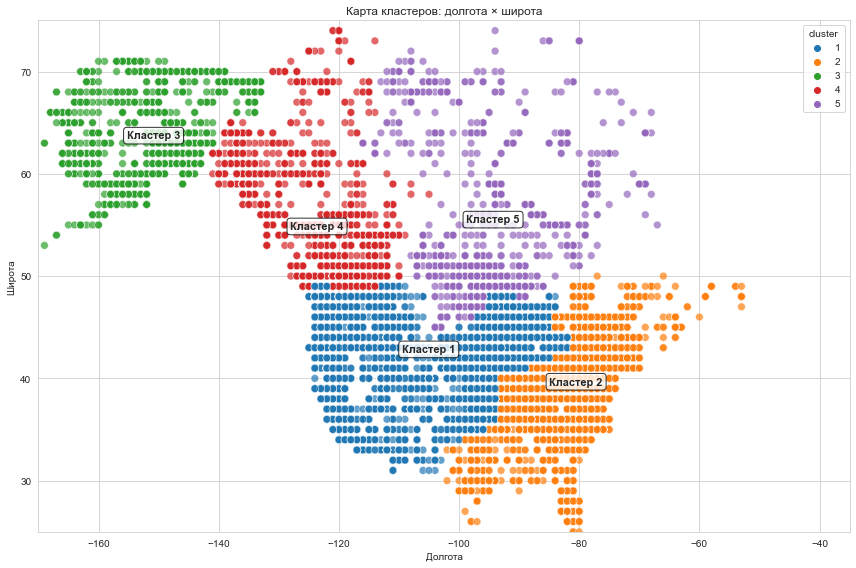

In [31]:
fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=data.dropna(subset=['cluster']),
    x='decimal_longitude', y='decimal_latitude',
    hue='cluster', palette='tab10', s=60, alpha=0.7, ax=ax, legend='full'
)
ax.set_title('Карта кластеров: долгота × широта')
ax.set_xlabel('Долгота')
ax.set_ylabel('Широта')
ax.set_xlim(-170, -35)
ax.set_ylim(25, 75)
# Центроиды
centroids = data.dropna(subset=['cluster']).groupby('cluster')[
    ['decimal_longitude', 'decimal_latitude']
].mean()

for cl, row in centroids.iterrows():
    ax.annotate(
        f'Кластер {cl}',
        xy=(row['decimal_longitude'], row['decimal_latitude']),
        fontsize=11, fontweight='bold',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='black', alpha=0.8),
        zorder=10
    )

plt.tight_layout()
plt.show()

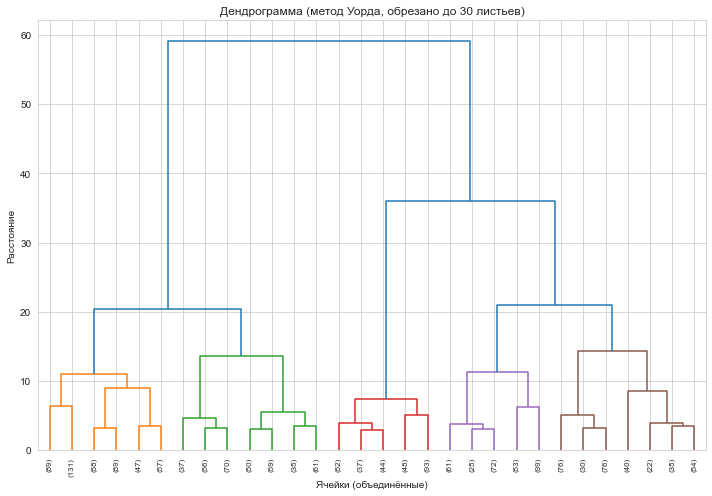

In [32]:
# 2. Дендрограмма
fig, ax = plt.subplots(figsize=(10, 7))

dendrogram(
    linkage_matrix,
    truncate_mode='lastp', p=30,
    leaf_rotation=90, leaf_font_size=8, ax=ax,
    color_threshold=linkage_matrix[-4, 2]  # порог для 5 кластеров
)
ax.set_title('Дендрограмма (метод Уорда, обрезано до 30 листьев)')
ax.set_xlabel('Ячейки (объединённые)')
ax.set_ylabel('Расстояние')

plt.tight_layout()
plt.show()

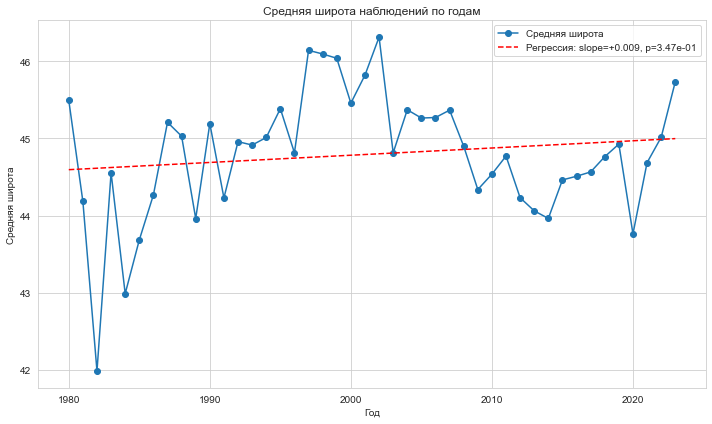

In [33]:
# 3. Тренд широты по годам с регрессией
fig, ax = plt.subplots(figsize=(10, 6))

year_lat = data.groupby('year')['decimal_latitude'].agg(['mean', 'count']).reset_index()
ax.plot(year_lat['year'], year_lat['mean'], marker='o', label='Средняя широта')

slope, intercept, r, p, se = linregress(year_lat['year'], year_lat['mean'])
ax.plot(year_lat['year'], intercept + slope * year_lat['year'],
        'r--', label=f'Регрессия: slope={slope:+.3f}, p={p:.2e}')

ax.set_title('Средняя широта наблюдений по годам')
ax.set_xlabel('Год')
ax.set_ylabel('Средняя широта')
ax.legend()

plt.tight_layout()
plt.show()

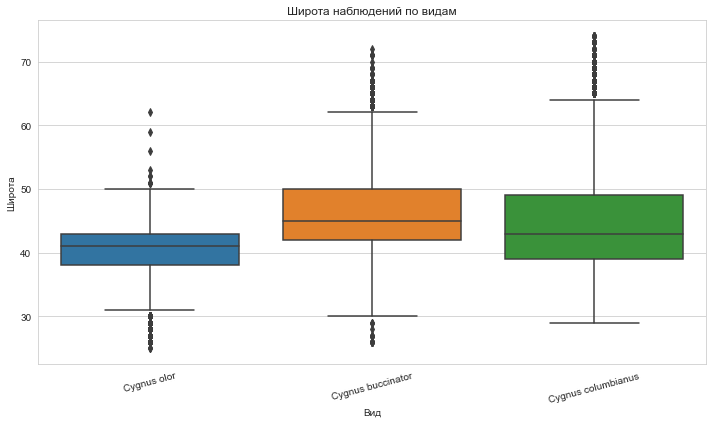

In [34]:
# 4. Boxplot: широта по видам
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=data, x='species', y='decimal_latitude', ax=ax)
ax.set_title('Широта наблюдений по видам')
ax.set_xlabel('Вид')
ax.set_ylabel('Широта')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

Карта кластеров, дендрограмма, тренд широты и boxplot по видам подтверждают: кластеры пространственно разделены, виды различаются по широте, общий тренд на юг присутствует.

## 22. Выводы

> TODO: сформулируйте выводы в текстовом блоке:
> - наблюдается ли смещение ареала?
> - различается ли оно по кластерам?
> - какие различия между видами и сезонами?
> - какие ограничения анализа?

1. Наблюдается ли смещение ареала?  
Да, наблюдается статистически значимое смещение на юг. В множественной регрессии коэффициент при годе отрицателен: −0.0366° широты в год (p < 0.001). По всем пяти кластерам тренды также отрицательны и значимы (p < 0.05). Однако эффект слабый: модель объясняет лишь 11.3% дисперсии широты, а R² по кластерам не превышает 0.084. То есть смещение есть, но оно небольшое и неоднородное. 


2. Различается ли смещение по кластерам?  
Да, различается. Наклоны варьируют от −0.0145°/год (кластер 1) до −0.2044°/год (кластер 5). Наиболее выражен тренд в кластере 5 (R² = 0.0843, p = 6.3e−27), тогда как в кластерах 1–4 R² очень малы (0.0017–0.0058), т.е. смещение там есть, но крайне слабое. Кластер 5 — северный (средняя широта 55.52°), и именно в нём сдвиг на юг наиболее заметен.  


3. Различия между видами и сезонами  
Виды значимо различаются по широте (Kruskal-Wallis H = 4528.09, p < 0.001) и температуре (H = 1502.71, p < 0.001). Все попарные сравнения видов по широте также значимы (Mann-Whitney, p < 0.001).
Сезоны значимо различаются по широте (Mann-Whitney U = 72 489 238, p < 0.001): летом птицы севернее (средняя широта 49.25°, медиана 45°), зимой южнее (41.78°, медиана 42°).  

По видам:  
Cygnus columbianus — наиболее мигрирующий: зимой 41.36°, летом 60.03° (сдвиг ~18.7°).  
Cygnus buccinator — промежуточный: 44.04° зимой, 50.30° летом (сдвиг ~6.3°).  
Cygnus olor — относительно оседлый: 39.95° зимой, 40.95° летом (сдвиг ~1.0°).  
Внутри сезонов температура отрицательно коррелирует с широтой: зимой ρ = −0.598, летом ρ = −0.869 (Spearman, p < 0.001).   Плотность населения также отрицательно связана с широтой (ρ = −0.693, p < 0.001): южнее плотность выше.  

4. Ограничения анализа  

Сильная агрегация данных: после округления координат и удаления дубликатов осталось 33 095 записей из ~3.03 млн, что снижает пространственное разрешение и может смещать результаты.

Неравномерность по годам: 40.8% записей приходится на 2016–2023 гг., что может отражать рост наблюдательской активности, а не реальное смещение ареала.

Низкая объясняющая способность моделей: R² множественной регрессии = 0.113, по кластерам — до 0.084.

Мультиколлинеарность: condition number = 3.86e+05.

Кластеризация только по координатам, без учёта экологических переменных.

Температура и плотность взяты на уровне штата/провинции, а не локально.

Данные любительских наблюдений, а не стандартизированных учётов; возможны искажения из-за разной вероятности обнаружения.

Корреляционный анализ не доказывает причинно-следственных связей.